In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

# Style settings for the plot
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# 
C_Points = "#2b6cb0"
C_Straight = "#e53e3e"
C_Tangent = "#dd6b20"
C_Optimal = "#38a169"
print("Plotting settings configured.")

Plotting settings configured.


## 1. Equation of a line: 
$$
y = mx + b
$$

Only two levers: a slope `m` (inclination) and the y-intercept `b` (where it crosses the y-axis).

The graph shows several lines: changing `m` makes it steeper, changing `b` makes it go up or down without changing the slope.

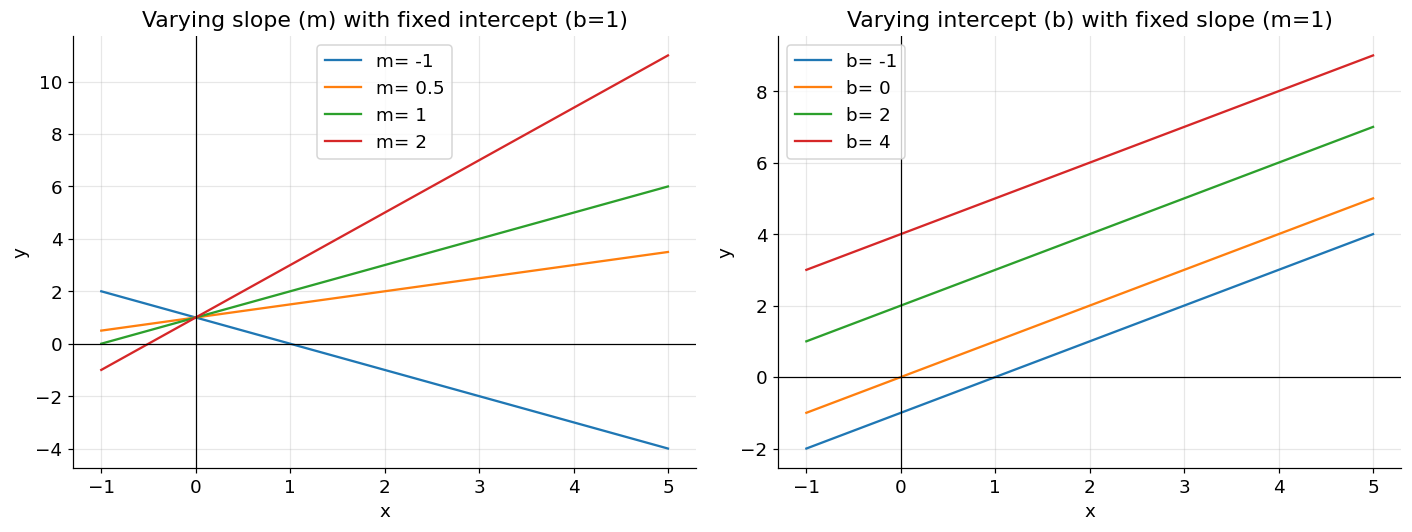

In [2]:
x = np.linspace(-1, 5, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Varying m (same b)
for m in [-1, 0.5, 1, 2]:
    ax1.plot(x, m*x + 1, label=f"m= {m}")

ax1.set_title("Varying slope (m) with fixed intercept (b=1)")
ax1.axhline(0, color = "k", lw=0.8); ax1.axvline(0, color= "k", lw=0.8)
ax1.legend()
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# Varying b (same m)
for b in [-1, 0, 2, 4]:
    ax2.plot(x, 1.0*x + b, label = f"b= {b}")

ax2.set_title("Varying intercept (b) with fixed slope (m=1)")
ax2.axhline(0, color = "k", lw=0.8); ax2.axvline(0, color= "k", lw=0.8)
ax2.legend()
ax2.set_xlabel("x")
ax2.set_ylabel("y")
plt.tight_layout()
plt.show()

## 2. Slope is a rate of change.

**Slope = by how much y changes ÷ by how much x changes**

On a **straight line**, this rate is the same at every point (it always rises the same amount for each step). On a **curve**, the slope changes: measuring between two distant points only gives an _average_.

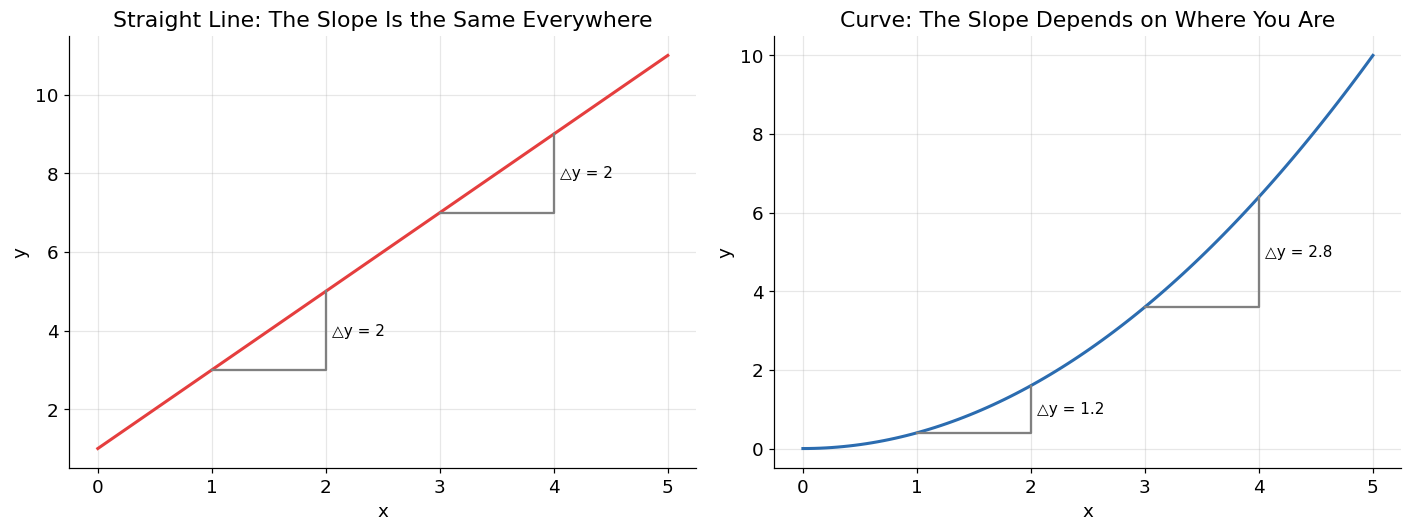

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Straight Line
xr = np.linspace(0, 5, 100)
m = 2
b = 1
y_line = m * xr + b

ax1.plot(xr, y_line, color=C_Straight, lw=2)

for x0 in [1, 3]:
    # Compute the exact points on the line
    y0 = m * x0 + b
    y1 = m * (x0 + 1) + b

    # The gray triangle now starts from the correct vertical position
    ax1.plot(
        [x0, x0 + 1, x0 + 1],
        [y0, y0, y1],
        color="gray",
        lw=1.5
    )

    ax1.text(
        x0 + 1.05,
        (y0 + y1) / 2,
        f"△y = {m}",
        va="center",
        fontsize=10
    )

ax1.set_title("Straight Line: The Slope Is the Same Everywhere")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# Plot 2: Curve
xc = np.linspace(0, 5, 100)
f = lambda x: 0.4 * x**2

ax2.plot(xc, f(xc), color=C_Points, lw=2)

for x0 in [1, 3]:
    dx = 1

    # Here the code correctly uses the function f(x)
    ax2.plot(
        [x0, x0 + dx, x0 + dx],
        [f(x0), f(x0), f(x0 + dx)],
        color="gray",
        lw=1.5
    )

    slope = (f(x0 + dx) - f(x0)) / dx

    ax2.text(
        x0 + dx + 0.05,
        (f(x0) + f(x0 + dx)) / 2,
        f"△y = {slope:.1f}",
        va="center",
        fontsize=10
    )

ax2.set_title("Curve: The Slope Depends on Where You Are")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

## 3. The Derivative: Slope at a Specific Point

To measure the slope _at a point_, you take a second point and move **it closer** to the first. The average slope (secant) becomes increasingly similar to the actual slope (tangent). In the limit, when the two points are almost touching, you obtain the **derivative**: the slope of the **tangent line**.

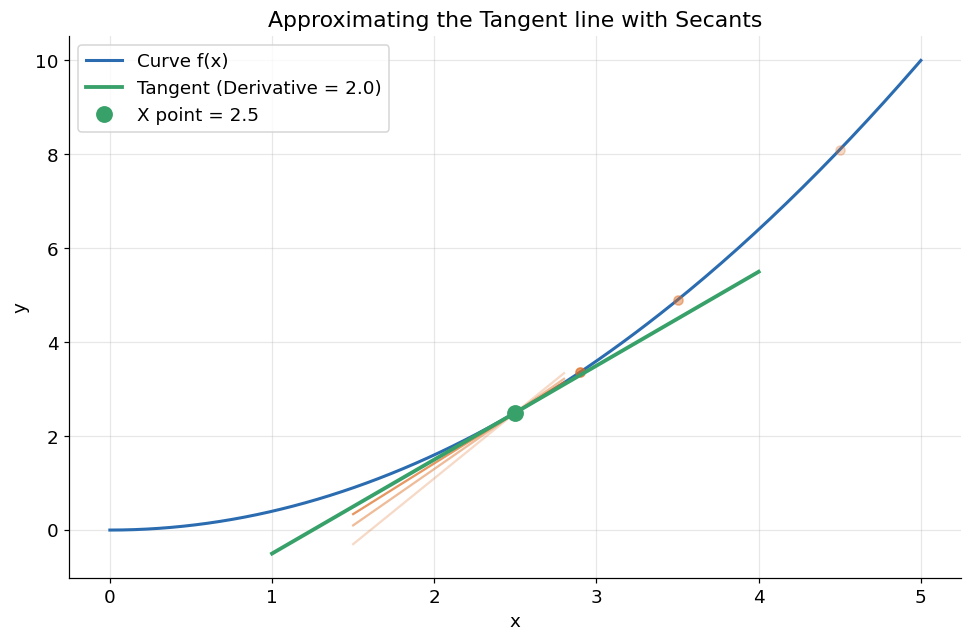

In [4]:
f = lambda x: 0.4 * x**2
df = lambda x: 0.8*x

x0 = 2.5
xc = np.linspace(0, 5, 200)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xc, f(xc), color=C_Points, lw = 2, label= "Curve f(x)")

# Plot tangents with varying h and alpha
for h, alpha in zip([2.0, 1.0, 0.4], [0.25, 0.45, 0.7]):
    x1 = x0 + h
    pend = (f(x1) - f(x0))/h
    xs = np.linspace(x0 - 1, x0+0.3, 10)
    ax.plot(xs, f(x0) + pend*(xs - x0), color=C_Tangent, alpha=alpha, lw=1.5 )
    ax.plot(x1, f(x1), "o", color=C_Tangent, alpha=alpha)

# Exact tangent line
pend_t = df(x0)
xs = np.linspace(x0 - 1.5, x0+1.5, 10)
ax.plot(xs, f(x0)+pend_t * (xs - x0), color=C_Optimal, lw=2.5, label=f"Tangent (Derivative = {pend_t:.1f})")
ax.plot(x0, f(x0), "o", color=C_Optimal, ms=10, label=f"X point = {x0}")

ax.set_title("Approximating the Tangent line with Secants")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()